# Deep Learning Fundamentals Compared to Traditional ML

## 📚 Learning Objectives 

By completing this notebook (~20 min), you will:
- Train a small neural network on an MNIST subset and see accuracy
- Train a traditional ML classifier (e.g. logistic regression) on the same data
- Compare why we use deep learning for raw images instead of hand-crafted features

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 3, lesson 01 "Logistic Regression and Classification Metrics" — the traditional classifier this notebook puts head-to-head with a neural network on the same pixels.

**Used later in:** Course 10 (AIAT 124) — Unit 1 — generative models are built out of the same layers.

---

## 🌍 Real life 

**📌 Real case — the cheque readers.** In 1998 LeCun, Bottou, Bengio and Haffner published the system behind NCR's cheque-reading machines (*Proceedings of the IEEE* 86(11)). Its abstract states the design "is deployed commercially and reads several million checks per day"; the paper adds that it "has been fielded in several banks across the United States since June 1996, and it has been reading millions of checks per day since then". Nobody wrote a rule for what a handwritten "7" looks like. The network learned it from examples of real cheques — which is exactly the difference this notebook measures.

**⚡ Why this matters — what goes wrong without it.** Traditional ML on images makes a human decide, in advance, what to measure: stroke thickness, hole count, the ratio of ink in each quadrant. Every one of those choices is a guess, every guess fails on a customer who writes differently, and each new task starts the guessing again. Below, logistic regression is handed all 784 raw pixels as fixed features and reaches **0.8879**; the network, given the identical 5,000 images, invents its own features and reaches **0.9130** — without you designing a single one.

**Where is this used?** Deep learning is used for **image recognition**, **speech**, **NLP** when we have raw high-dimensional data. Traditional ML (e.g. logistic regression, random forest) is still used for **tabular data** and when we have **hand-designed features** or limited data.

**In this notebook we use** a **feedforward neural network** to classify digits from **raw pixels** (MNIST). We use **deep learning** (instead of traditional ML on raw pixels) **because** the NN learns useful features from the data automatically; a simple classifier on raw pixels usually does worse unless we first engineer features.

**📌 Covers slide(s):** **08** — Fundamentals of Deep Learning (vs traditional ML). *Do this notebook after that slide in class.*

---

**Before starting:** Run the imports cell below.


## Theory (short) 

- **Traditional ML:** Often needs **hand-designed features** (e.g. edges, histograms). Model (e.g. logistic regression, SVM) then learns on top of those features.
- **Deep learning:** The network learns **features from raw data** (e.g. pixels) via layers; we don't hand-design them.
- **When to use which:** DL excels when we have **lots of data** and **raw signals** (images, text, audio). Traditional ML is strong for **tabular data**, small data, or when we already have good features.
- **We use a NN on raw pixels here** instead of only logistic regression on raw pixels because the NN can learn non-linear boundaries and feature hierarchies.

**The steps below put this theory into code.**

## 📥 Inputs & 📤 Outputs 

**Inputs:** NumPy, TensorFlow, scikit-learn. We use a small MNIST subset (e.g. 5000 samples) so the notebook runs quickly.

**Dataset:** Real — MNIST (handwritten digits 0–9). Used so the example mimics a real-world image classification task.

**Outputs:** Printed accuracy for (1) the neural network and (2) logistic regression on the same test set, plus one figure that shows *where* the gap is: errors per digit for both models, and real test images the network reads correctly and logistic regression does not.

**Expected:** NN test accuracy typically ~0.90–0.95, LR ~0.88–0.92 on this subset; the comparison sentence should state that the NN learns from raw pixels and usually does better than LR on images.

## Step 1: Imports and load MNIST subset

In [1]:
# Step 1: Imports and load MNIST subset (small subset for fast run)
# WHY: both models will see exactly the same data, so the deep-vs-traditional comparison is fair.
import numpy as np

# Import the heavy libraries inside try/except so a missing install gives a helpful message, not a crash.
try:
    import tensorflow as tf
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    HAS_DEPS = True
except ImportError:
    HAS_DEPS = False

# Only proceed when the libraries exist; otherwise tell the student what to install.
if not HAS_DEPS:
    print("Install: pip install tensorflow scikit-learn")
else:
    # Fix the random seed so every run prints the SAME accuracy the text below quotes
    # (weight initialisation and batch shuffling are random otherwise).
    tf.keras.utils.set_random_seed(42)
    # Load MNIST, scale pixels to 0-1, and flatten each 28x28 image into a 784-long vector.
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    # Keep only 5,000 training images so the notebook runs in seconds, not minutes.
    n_subset = 5000
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    x_train_flat = x_train.reshape(-1, 784)[:n_subset]
    y_train_sub = y_train[:n_subset]
    x_test_flat = x_test.reshape(-1, 784)
    print("Train subset:", x_train_flat.shape, "Test:", x_test_flat.shape)

Train subset: (5000, 784) Test: (10000, 784)


## Step 2: Train a small neural network (we use a NN to learn features from raw pixels instead of hand-crafted features)

In [2]:
# Step 2: Build, compile, train NN; evaluate on test set
# WHY: this is the deep-learning side of the comparison - the network learns its own features from raw pixels.
if HAS_DEPS:
    # Two-layer network: 128 ReLU units find pixel patterns; softmax turns 10 scores into digit probabilities.
    model_nn = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation="relu", input_shape=(784,)),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    # Adam optimizer + cross-entropy loss is the standard recipe for multi-class classification.
    model_nn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model_nn.fit(x_train_flat, y_train_sub, epochs=3, batch_size=64, verbose=0)
    # Evaluate on images the model never saw - the only honest measure of learning.
    _, acc_nn = model_nn.evaluate(x_test_flat, y_test, verbose=0)
    print("Neural network test accuracy: %.4f" % acc_nn)
else:
    acc_nn = None

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural network test accuracy: 0.9130


## Step 3: Train logistic regression on the same flattened pixels (traditional ML on raw pixels)

In [3]:
# Step 3: Scale features, train logistic regression, compare to NN
# WHY: the traditional-ML side of the comparison - same data, but the model treats raw pixels as fixed features.
if HAS_DEPS:
    # Standardize each pixel column so logistic regression's optimizer converges reliably.
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train_flat)
    x_test_scaled = scaler.transform(x_test_flat)
    # Logistic regression: one linear map + softmax - no hidden layers, no learned features.
    lr = LogisticRegression(max_iter=500)
    lr.fit(x_train_scaled, y_train_sub)
    acc_lr = lr.score(x_test_scaled, y_test)
    print("Logistic regression test accuracy: %.4f" % acc_lr)
    print("\nComparison: NN learns features from pixels; LR uses raw pixels as features. NN typically does better on images.")

Logistic regression test accuracy: 0.8879

Comparison: NN learns features from pixels; LR uses raw pixels as features. NN typically does better on images.


## Step 4: Look at the difference, do not just read it

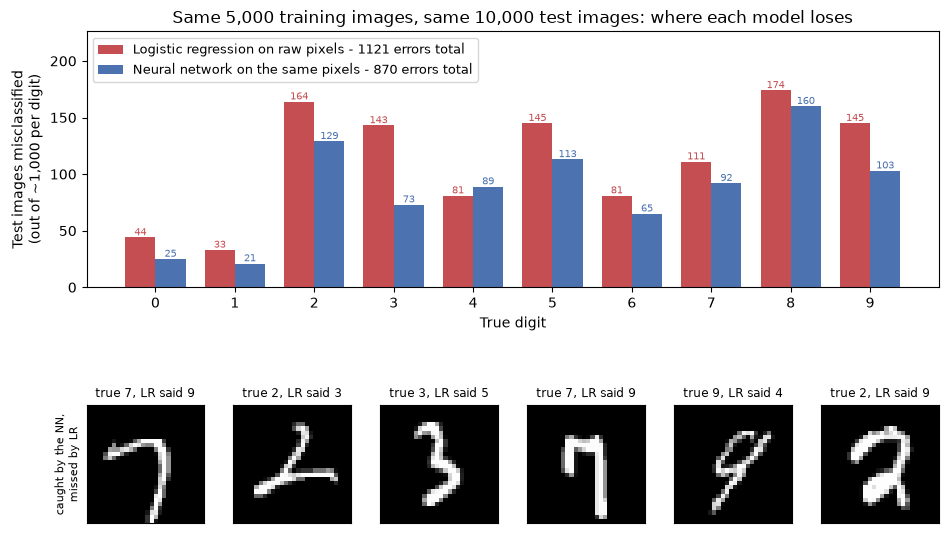

Errors  logistic regression: 1121 / 10000   (accuracy 0.8879)
Errors  neural network     :  870 / 10000   (accuracy 0.9130)
The network makes fewer errors on 9 of the 10 digits.
Biggest single-digit gain: digit 3 (143 -> 73 errors).
Test images LR gets wrong but the network gets right: 463


In [4]:
# Step 4: SEE the comparison - where the errors fall, and which digits the gap is made of
# WHAT: reuse the two models trained above (no retraining) and draw two things:
#       (top)    how many test digits each model gets wrong, digit by digit;
#       (bottom) real test images that logistic regression misses and the network gets right.
# WHY: a printed accuracy hides WHERE the gap comes from; these two panels show it.
import matplotlib.pyplot as plt

if HAS_DEPS:
    # Predictions from the already-trained models on the same 10,000 test images.
    pred_nn = model_nn.predict(x_test_flat, verbose=0).argmax(axis=1)
    pred_lr = lr.predict(x_test_scaled)

    digit_ids = np.arange(10)
    # Count errors per true digit (each digit has roughly 1,000 test images).
    err_nn = np.array([int((pred_nn[y_test == d] != d).sum()) for d in digit_ids])
    err_lr = np.array([int((pred_lr[y_test == d] != d).sum()) for d in digit_ids])

    fig = plt.figure(figsize=(11, 6.6))
    gs = fig.add_gridspec(2, 6, height_ratios=[1.7, 1.0], hspace=0.5, wspace=0.25)

    # --- Top panel: error counts per digit, both models side by side -------------
    ax = fig.add_subplot(gs[0, :])
    w = 0.38
    ax.bar(digit_ids - w / 2, err_lr, w, color="#c44e52",
           label=f"Logistic regression on raw pixels - {err_lr.sum()} errors total")
    ax.bar(digit_ids + w / 2, err_nn, w, color="#4c72b0",
           label=f"Neural network on the same pixels - {err_nn.sum()} errors total")
    for d in digit_ids:  # print the counts so the gap is readable, not only visible
        ax.text(d - w / 2, err_lr[d] + 2, str(err_lr[d]), ha="center", fontsize=7.5, color="#c44e52")
        ax.text(d + w / 2, err_nn[d] + 2, str(err_nn[d]), ha="center", fontsize=7.5, color="#4c72b0")
    ax.set_xticks(digit_ids)
    ax.set_xlabel("True digit")
    ax.set_ylabel("Test images misclassified\n(out of ~1,000 per digit)")
    ax.set_title("Same 5,000 training images, same 10,000 test images: where each model loses")
    ax.legend(loc="upper left", fontsize=9)
    ax.set_ylim(0, max(err_lr.max(), err_nn.max()) * 1.30)

    # --- Bottom panels: the digits the network catches and the linear model misses ---
    caught = np.where((pred_lr != y_test) & (pred_nn == y_test))[0][:6]
    for k, idx in enumerate(caught):
        axk = fig.add_subplot(gs[1, k])
        axk.imshow(x_test[idx], cmap="gray")           # the real 28x28 test image
        axk.set_xticks([]); axk.set_yticks([])
        axk.set_title(f"true {y_test[idx]}, LR said {pred_lr[idx]}", fontsize=8.5)
        if k == 0:
            axk.set_ylabel("caught by the NN,\nmissed by LR", fontsize=8)

    plt.show()

    # The numbers behind the caption, printed so you can check the picture against them.
    print(f"Errors  logistic regression: {err_lr.sum():4d} / 10000   (accuracy {1 - err_lr.sum()/10000:.4f})")
    print(f"Errors  neural network     : {err_nn.sum():4d} / 10000   (accuracy {1 - err_nn.sum()/10000:.4f})")
    print(f"The network makes fewer errors on {int((err_nn < err_lr).sum())} of the 10 digits.")
    worst = int(np.argmax(err_lr - err_nn))
    print(f"Biggest single-digit gain: digit {worst} ({err_lr[worst]} -> {err_nn[worst]} errors).")
    print(f"Test images LR gets wrong but the network gets right: {int(((pred_lr != y_test) & (pred_nn == y_test)).sum())}")


**Read the figure.**

- **Top panel** — for each digit 0-9 the red bar is how many of that digit's ~1,000 test images logistic regression misclassifies; the blue bar is the network's count on *exactly the same images*. Blue is shorter for 9 of the 10 digits. The exception is digit **4** (81 red vs 89 blue): the network is not uniformly better, and the honest sentence is "better on average", not "better everywhere". Biggest single gain: digit **3**, 143 errors down to 73. The totals 1,121 vs 870 are the same 0.8879 vs 0.9130 accuracies printed above — the picture adds *where*, not a new claim.
- **Bottom panel** — six of the **463** test images logistic regression gets wrong while the network gets them right. Each title states the true digit and what logistic regression answered. These 463 images, minus the ones the network loses in return, *are* the 2.5 accuracy points; the gap is not an abstraction, it is this pile of slanted sevens and open twos.

**What it proves:** a linear model scores every image with one fixed weight per pixel, so a digit written off-centre or at a slant falls outside its template. The network's hidden layer can combine pixels non-linearly and recovers many of those. **What it does not prove:** that deep learning always wins — see digit 4, and see "Where this breaks" below.

## 💬 Discuss

Argue these out loud with your neighbour before moving on — none of them has a single right answer.

1. The network beat logistic regression by **2.5 points** (0.9130 vs 0.8879) on 5,000 images. Your client says: "2.5 points is not worth buying a GPU." Are they wrong? Name the one experiment you would run to answer them, and say in advance what result would change *your* mind.
2. MNIST digits arrive centred, size-normalised and on clean white. A photograph of a handwritten Saudi postal code on a parcel violates all three. Which of the two models degrades more gracefully, and why?
3. Both models saw exactly the same 5,000 images. If your client can only give you 300 labelled images instead, which model do you propose, and what do you tell them about the accuracy they should expect?


## 🌍 Real-World Worked Example — Handwritten Digit Recognition

**Industry context:** The US Postal Service has been using digit recognition since the 1980s.  
ATMs, banks, and postal systems worldwide classify millions of handwritten digits daily.

Below we train a neural network on **real** digit images (same family as MNIST, 8×8 pixels, sklearn built-in — no download needed).

*Preview: this example uses a full PyTorch training loop, which notebooks `02`–`03` introduce step by step. Run it as a demo now and revisit the code after those notebooks.*

Test accuracy on real handwritten digits: 96.9%


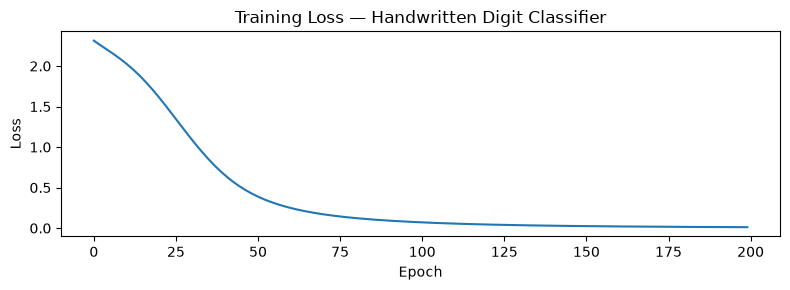

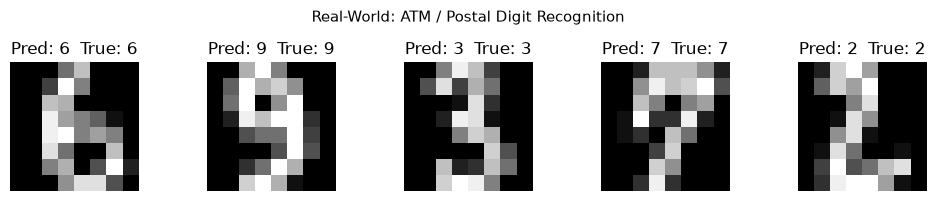

In [5]:
import torch, torch.nn as nn, torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

# ── Real digit images (1797 samples, 8×8 pixels) ──────────────────────────
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target

# Split FIRST (the 8×8 images travel with their rows), then scale with
# statistics from the training set only (no test-set leakage).
X_tr, X_te, y_tr, y_te, img_tr, img_te = train_test_split(
    X, y, digits.images, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr).astype(np.float32)
X_te = scaler.transform(X_te).astype(np.float32)

X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te, dtype=torch.long)

# ── Two-layer neural network ───────────────────────────────────────
# Fix the seed so this demo prints the same accuracy every run (and the same number
# in notebooks 01, 02 and 03, which all run this identical example).
torch.manual_seed(0)
model = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss()
losses    = []

for epoch in range(200):
    model.train()
    pred = model(X_tr_t)
    loss = loss_fn(pred, y_tr_t)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())

# ── Evaluation ──────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    acc = (model(X_te_t).argmax(1) == y_te_t).float().mean().item()

print(f"Test accuracy on real handwritten digits: {acc*100:.1f}%")

# ── Plot training loss ──────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Training Loss — Handwritten Digit Classifier"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()

# ── Show sample predictions: test images paired with their own labels ─────
with torch.no_grad():
    sample_preds = model(X_te_t[:5]).argmax(1).tolist()

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(img_te[i], cmap='gray')   # the SAME test image the model predicted on
    ax.set_title(f"Pred: {sample_preds[i]}  True: {y_te[i]}")
    ax.axis('off')
plt.suptitle("Real-World: ATM / Postal Digit Recognition", fontsize=11)
plt.tight_layout(); plt.show()

**Read the two figures.**

- **Loss curve** — a 3-layer network on 1,437 real 8×8 digit images, full batch, 200 epochs. It starts at about **2.3**, which is ln 10: the loss of a model answering "all ten digits equally likely". By epoch 200 it is essentially 0. That is *training* loss, on images the model is free to memorise, so on its own it proves nothing.
- **Five test digits** — images from the 360 held-out samples the model never trained on, each with its prediction and true label. All five are right, and the honest number is next to them: **96.9%** on the whole held-out set.

**Careful with both.** A training-loss curve that reaches zero and five hand-picked correct predictions are the two most common ways a result gets oversold. The claim that survives review is the held-out accuracy — and better still, a confusion matrix over every test image (notebook 02, Step 9).

## ⚠️ Where this breaks

**When NOT to reach for deep learning.**

- **Small data.** Our network needed 5,000 labelled images to reach 0.9130. On 200 labelled examples a regularised linear model or gradient boosting will normally win, and it will train in a second rather than a minute.
- **Tabular data.** Grinsztajn, Oyallon & Varoquaux (NeurIPS 2022, arXiv 2207.08815) benchmarked tree ensembles against neural networks on 45 datasets and concluded that "tree-based models remain state-of-the-art on medium-sized data (~10K samples)". If your input is a spreadsheet, start with XGBoost, not a network.
- **The gap here is 2.5 points, not a revolution.** MNIST is centred, size-normalised and monochrome — nearly the friendliest image task that exists, which is why a linear model on raw pixels already gets 0.8879. On harder images the gap widens; on this one, be honest about its size.
- **The assumption that must hold:** the *raw* signal contains the structure worth learning (pixels, audio samples, characters). If a domain expert has already handed you twelve well-chosen features, there is little left for a network to discover, and you have given up interpretability for nothing.
- **What you lose:** logistic regression gives one weight per pixel that you can print and inspect. This network has 101,770 numbers that explain nothing. For a bank that must justify a rejected cheque to a customer, that is not a small cost.

**🔁 The same trade-off appears elsewhere:** credit scoring (regulators often require an inspectable linear model over a more accurate network), industrial sensor monitoring (a threshold on one well-chosen feature beats a network and never needs a GPU), and Arabic OCR (where letter shape depends on position in the word, so hand-designed features multiply while learned ones do not).


## 🧩 Mini-exercise 

**Try it (choose one):**
- Change `n_subset` (e.g. from 5000 to 2000 or 10000) and run the notebook again. How does test accuracy change for the NN and for logistic regression?
- Add one more Dense layer (e.g. 64 units, ReLU) to the NN, then retrain. Does accuracy improve?

*Add a new code cell below, make the change, run it, and compare. Then continue to the Summary.*

---

## ✅ Summary 

**What you did:**
- Trained a small NN and logistic regression on the same MNIST subset.
- Compared test accuracy; the NN usually does better on raw pixels because it learns non-linear features.

**In real life you'd also:** Use validation sets, tune hyperparameters, and for traditional ML you might engineer image features (e.g. HOG) and then use LR.

**The main idea:** Deep learning learns features from raw data; traditional ML often relies on hand-designed features. For raw images, a NN typically outperforms a linear model on pixels.

**Next:** `02_simple_neural_network` builds the NN step by step; `03_perceptron_mlp_tensorflow_pytorch_setup` shows perceptron and MLP in TF/PyTorch.

## 📚 References

1. Rumelhart, D. E., Hinton, G. E. & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature 323, 533-536. https://doi.org/10.1038/323533a0
2. LeCun, Y., Bengio, Y. & Hinton, G. (2015). *Deep learning*. Nature 521, 436-444. https://www.nature.com/articles/nature14539
3. Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning* (ch. 1). MIT Press. https://www.deeplearningbook.org/
4. Kaplan, J. et al. (2020). *Scaling Laws for Neural Language Models*. arXiv. https://arxiv.org/abs/2001.08361

**Recent work (2024–2026)**

5. Grinsztajn et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. arXiv. https://arxiv.org/abs/2511.08667 — the deep-learning-versus-classical-ML comparison in this lesson has a 2025 sequel on tabular data: a *pretrained* transformer that predicts in context reports beating tuned tree ensembles with no per-dataset training at all.
6. Grinsztajn et al. (2026). *TabPFN-3: Technical Report*. arXiv. https://arxiv.org/abs/2605.13986 — the same idea scaled to roughly a million training rows. Before you tell a client that gradient boosting is the tabular ceiling, benchmark against one of these.
